# EDA — INE ADRH (Source 1)

**Source:** Atlas de Distribución de Renta de los Hogares (INE)  
**S3:** `s3://hsf-group-ai-spain-hvac/ine-adrh/raw/` — 21 zstd-compressed files (CSV + JSON)  
**Documentation:** `INE_ADRH_DATA_DOCUMENTATION.md`

This notebook covers:
1. How to read raw ADRH tables from S3
2. The generated parquet files in `data/generated/adrh/` — what each contains and how it was produced
3. Key distributions relevant to HVAC propensity modelling

In [1]:
import gc, io, json, re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import boto3, zstd

BUCKET = "hsf-group-ai-spain-hvac"
AWS_PROFILE = "AWSAdministratorAccess-268271485741"
GENERATED = Path("data/generated/adrh")
CACHE_DIR = Path("data/cache/adrh")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

session = boto3.Session(profile_name=AWS_PROFILE)
s3 = session.client("s3")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

## 1. Reading raw ADRH tables from S3

All 10 ADRH tables are stored as zstd-compressed CSV and JSON files on S3.  
Table IDs: 30824–30832, 37677. See `INE_ADRH_DATA_DOCUMENTATION.md` for what each table covers.

In [2]:
def read_adrh_csv(table_id: str) -> pd.DataFrame:
    """Read an ADRH CSV table from S3, caching locally as parquet on first access."""
    cache_path = CACHE_DIR / f"{table_id}.parquet"
    if cache_path.exists():
        print(f"[cache] {table_id} ← {cache_path}")
        return pd.read_parquet(cache_path)
    print(f"[s3] {table_id} — downloading and decompressing...")
    obj = s3.get_object(Bucket=BUCKET, Key=f"ine-adrh/raw/{table_id}.csv.zst")
    raw = zstd.decompress(obj["Body"].read())
    df = pd.read_csv(
        io.BytesIO(raw), sep=";", encoding="utf-8-sig", decimal=",", thousands=".",
    )
    df.to_parquet(cache_path, index=False)
    print(f"[s3] {table_id} — cached to {cache_path}  ({len(df):,} rows)")
    return df

### 1.2 JSON format — structure and field inspection

Same rows and geographic granularity as the CSV, but each series carries extra metadata:
`COD` (stable INE series identifier), `T3_Unidad` (unit), `T3_Escala` (scale factor), full ISO-8601 timestamps.
Using table 37677 (smallest file, ~165 MB raw / ~5 MB compressed) to inspect the live structure.

In [3]:
def read_adrh_json_raw(table_id: str) -> list:
    """Read an ADRH JSON table from S3, caching compressed bytes locally."""
    cache_path = CACHE_DIR / f"{table_id}.json.zst"
    if cache_path.exists():
        print(f"[cache] {table_id}.json ← {cache_path}")
        raw = zstd.decompress(cache_path.read_bytes())
    else:
        print(f"[s3] {table_id}.json — downloading...")
        obj = s3.get_object(Bucket=BUCKET, Key=f"ine-adrh/raw/{table_id}.json.zst")
        compressed = obj["Body"].read()
        cache_path.write_bytes(compressed)
        raw = zstd.decompress(compressed)
        print(f"[s3] cached to {cache_path}  ({cache_path.stat().st_size/1e6:.1f} MB)")
    data = json.loads(raw.decode("utf-8"))
    print(f"Loaded: {len(data):,} series objects")
    return data

In [4]:
data = read_adrh_json_raw("37677")

print("=== Keys in each series object ===")
print(list(data[0].keys()))
print()

print("=== First series — metadata fields ===")
for k, v in data[0].items():
    if k != "Data":
        print(f"  {k!r:20s}: {v!r}")
print()

print("=== First series — Data array (first 3 records) ===")
for d in data[0]["Data"][:3]:
    print(f"  {d}")
print()

print("=== First sección-level series ===")
for i, entry in enumerate(data):
    if "secci" in entry.get("Nombre", "").lower():
        print(f"Index {i}: {entry['Nombre'][:120]}")
        for k, v in entry.items():
            if k != "Data":
                print(f"  {k!r:20s}: {v!r}")
        print(f"  'Data'[:3]          : {entry['Data'][:3]}")
        break
print()

print("=== Coverage summary ===")
total     = len(data)
secciones = sum(1 for e in data if "secci" in e.get("Nombre", "").lower())
distritos = sum(1 for e in data if "distrito" in e.get("Nombre", "").lower())
municipal = total - secciones - distritos
units     = sorted(set(e.get("T3_Unidad", "") for e in data if e.get("T3_Unidad")))
scales    = sorted(set(e.get("T3_Escala") for e in data))
print(f"  Total series : {total:,}")
print(f"  Municipal    : {municipal:,}")
print(f"  Distritos    : {distritos:,}")
print(f"  Secciones    : {secciones:,}")
print(f"  Units seen   : {units}")
print(f"  Scales seen  : {scales}")
del data; gc.collect()

[s3] 37677.json — downloading...
[s3] cached to data/cache/adrh/37677.json.zst  (3.1 MB)
Loaded: 111,454 series objects
=== Keys in each series object ===
['COD', 'Nombre', 'T3_Unidad', 'T3_Escala', 'MetaData', 'Data']

=== First series — metadata fields ===
  'COD'               : 'ADRH9617523'
  'Nombre'            : 'Alegría-Dulantzi. Dato base. Índice de Gini. '
  'T3_Unidad'         : 'Porcentaje'
  'T3_Escala'         : ' '
  'MetaData'          : [{'Id': 6080, 'T3_Variable': 'Municipios', 'Nombre': 'Alegría-Dulantzi', 'Codigo': '01001'}, {'Id': 72, 'T3_Variable': 'Tipo de dato', 'Nombre': 'Dato base', 'Codigo': ''}, {'Id': 382445, 'T3_Variable': 'SALDOS CONTABLES', 'Nombre': 'Índice de Gini', 'Codigo': ''}]

=== First series — Data array (first 3 records) ===
  {'Fecha': '2023-01-01T00:00:00.000+01:00', 'T3_TipoDato': 'Definitivo', 'T3_Periodo': 'A', 'Anyo': 2023, 'Valor': 27.4}
  {'Fecha': '2022-01-01T00:00:00.000+01:00', 'T3_TipoDato': 'Definitivo', 'T3_Periodo': 'A', 'Anyo': 

160

## 2. Generated files in `data/generated/adrh/`

These files were produced by processing raw ADRH tables. Each cell below inspects one file.

### 2.1 `adrh_secciones_renta.parquet`
**Produced by:** `adrh_secciones.py`  
**Source table:** 31097 (renta media y mediana)  
**Format:** wide — one row per (sección censal × year), columns are income indicators  
**Years:** 2015–2023

In [5]:
renta = pd.read_parquet(GENERATED / "adrh_secciones_renta.parquet")
print(f"Shape: {renta.shape}")
print(f"Years: {sorted(renta['periodo'].unique())}")
print(f"Secciones: {renta['cod_seccion'].nunique():,}")
print(f"Columns: {list(renta.columns)}")
renta.head(3)

Shape: (39689, 11)
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Secciones: 4,537
Columns: ['cod_seccion', 'cod_provincia', 'cod_municipio', 'municipio', 'periodo', 'renta_media_uc', 'renta_mediana_uc', 'renta_bruta_media_hogar', 'renta_bruta_media_persona', 'renta_neta_media_hogar', 'renta_neta_media_persona']


,cod_seccion,cod_provincia,cod_municipio,municipio,periodo,renta_media_uc,renta_mediana_uc,renta_bruta_media_hogar,renta_bruta_media_persona,renta_neta_media_hogar,renta_neta_media_persona
0,2800101001,28,28001,"28001 Acebeda, La",2020,NaN,NaN,32211.0,16452.0,27408.0,13999.0
1,2800101001,28,28001,"28001 Acebeda, La",2021,NaN,NaN,32418.0,18151.0,27228.0,15245.0
2,2800101001,28,28001,"28001 Acebeda, La",2022,NaN,NaN,34844.0,18690.0,29297.0,15715.0


### 2.2 `30824_secciones.parquet`, `30825_secciones.parquet`, `30826_secciones.parquet`
**Produced by:** `download_adrh_remaining.py`  
**Format:** long — one row per (sección censal × year × indicator)  
**Columns:** `cod_seccion`, `año`, `indicador`, `valor`, `unidad`  

These are intermediate extracts of tables 30824 (income distribution), 30825 (poverty thresholds), 30826 (income sources) filtered to sección censal level.

In [6]:
for table_id in ["30824", "30825", "30826"]:
    df = pd.read_parquet(GENERATED / f"{table_id}_secciones.parquet")
    print(f"\n{table_id}_secciones.parquet")
    print(f"  Shape:      {df.shape}")
    print(f"  Years:      {sorted(df['año'].unique())}")
    print(f"  Secciones:  {df['cod_seccion'].nunique():,}")
    print(f"  Indicators: {list(df['indicador'].unique())[:4]} ...")


30824_secciones.parquet
  Shape:      (1879892, 5)
  Years:      [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Secciones:  36,994
  Indicators: ['Dato base. Renta neta media por persona. ', 'Dato base. Renta neta media por hogar. ', 'Dato base. Media de la renta por unidad de consumo. ', 'Dato base. Mediana de la renta por unidad de consumo. '] ...

30825_secciones.parquet
  Shape:      (1507392, 5)
  Years:      [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Secciones:  35,782
  Indicators: ['Porcentaje. Fuente de ingreso: salario. ', 'Porcentaje. Fuente de ingreso: otros ingresos. ', 'Porcentaje. Fuente de ingreso: pensiones. ', 'Porcentaje. Fuente de ingreso: prestaciones por desempleo. '] ...

30826_secciones.parquet
  Shape:      (2524050, 5)
  Years:      [np.int64(2015), np.int64(

## 3. Key HVAC distributions (2023)

All plots use `adrh_secciones_2023_wide.parquet` (built in section 4).
Run section 4 first if the file does not exist yet.

Column groups are detected automatically from column names — no hardcoded names.

In [7]:
adrh = pd.read_parquet(GENERATED / "adrh_secciones_2023_wide.parquet")
print(f"Shape: {adrh.shape}")

income_cols  = [c for c in adrh.columns if c != "cod_seccion"
                and re.search(r"renta|media_de_la_renta|mediana_de_la_renta", c)
                and not c.startswith("fuente")]
source_cols  = [c for c in adrh.columns if c.startswith("fuente_de_ingreso")]
poverty_cols = [c for c in adrh.columns if "por_debajo" in c]

threshold   = adrh.shape[0] * 0.5
coverage    = adrh[income_cols].notna().sum()
income_high = coverage[coverage > threshold].index.tolist()
income_low  = coverage[coverage <= threshold].index.tolist()

print(f"\nIncome high-coverage   n={len(income_high)}: {income_high}")
print(f"Income partial (31097) n={len(income_low)}:  {income_low}")
print(f"Income sources         n={len(source_cols)}:  {source_cols}")
print(f"Poverty thresholds     n={len(poverty_cols)}: {poverty_cols}")

Shape: (36395, 21)

Income high-coverage   n=6: ['media_de_la_renta_por_unidad_de_consumo', 'mediana_de_la_renta_por_unidad_de_consumo', 'renta_bruta_media_por_hogar', 'renta_bruta_media_por_persona', 'renta_neta_media_por_hogar', 'renta_neta_media_por_persona']
Income partial (31097) n=6:  ['renta_media_uc', 'renta_mediana_uc', 'renta_bruta_media_hogar', 'renta_bruta_media_persona', 'renta_neta_media_hogar', 'renta_neta_media_persona']
Income sources         n=5:  ['fuente_de_ingreso_otras_prestaciones', 'fuente_de_ingreso_otros_ingresos', 'fuente_de_ingreso_pensiones', 'fuente_de_ingreso_prestaciones_por_desempleo', 'fuente_de_ingreso_salario']
Poverty thresholds     n=3: ['poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_10_000_euros', 'poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_5_000_euros', 'poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_7_500_euros']


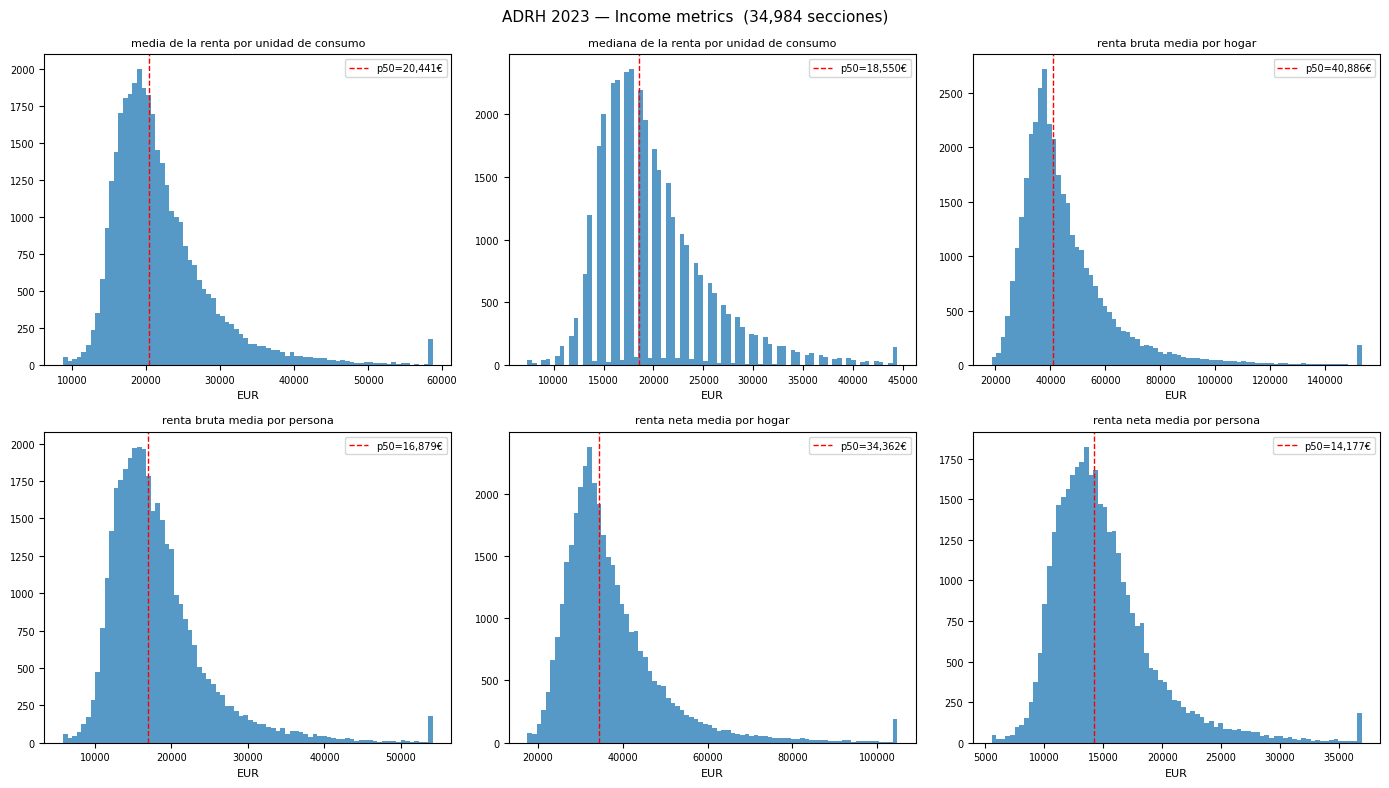

In [8]:
n = len(income_high)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for i, col in enumerate(income_high):
    data = adrh[col].dropna()
    axes[i].hist(data, bins=80, alpha=0.75, edgecolor="none")
    med = data.median()
    axes[i].axvline(med, color="red", linestyle="--", linewidth=1, label=f"p50={med:,.0f}€")
    axes[i].set_title(col.replace("_", " "), fontsize=8)
    axes[i].set_xlabel("EUR", fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f"ADRH 2023 — Income metrics  ({adrh[income_high[0]].notna().sum():,} secciones)",
    fontsize=11,
)
plt.tight_layout()
plt.show()
del data

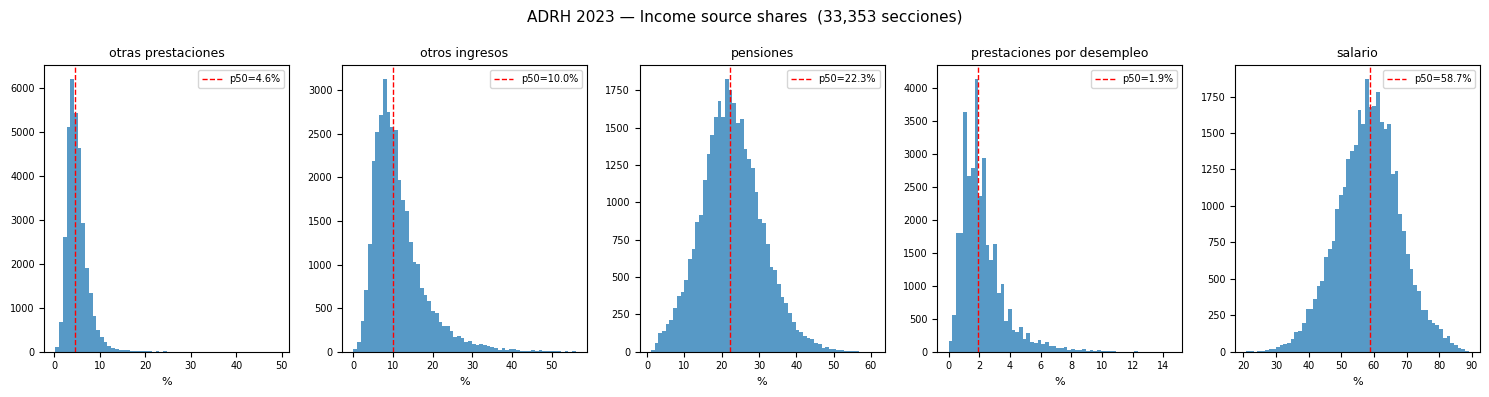

In [9]:
n = len(source_cols)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
if n == 1:
    axes = [axes]

for i, col in enumerate(source_cols):
    data = adrh[col].dropna()
    label = col.replace("fuente_de_ingreso_", "").replace("_", " ")
    axes[i].hist(data, bins=60, alpha=0.75, edgecolor="none")
    med = data.median()
    axes[i].axvline(med, color="red", linestyle="--", linewidth=1, label=f"p50={med:.1f}%")
    axes[i].set_title(label, fontsize=9)
    axes[i].set_xlabel("%", fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

fig.suptitle(
    f"ADRH 2023 — Income source shares  ({adrh[source_cols[0]].notna().sum():,} secciones)",
    fontsize=11,
)
plt.tight_layout()
plt.show()
del data

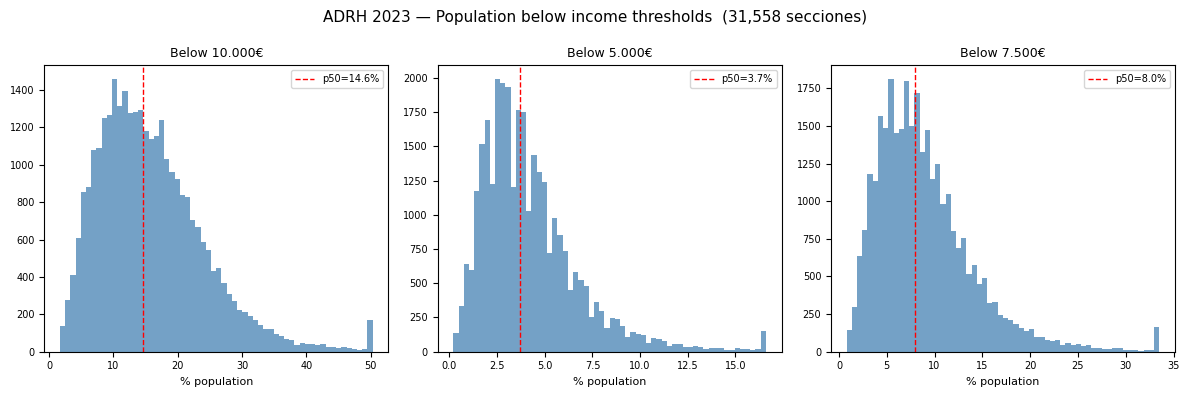

In [10]:
n = len(poverty_cols)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for i, col in enumerate(sorted(poverty_cols)):
    data = adrh[col].dropna()
    m = re.search(r"de_(\d+(?:_\d+)?)_euros", col)
    threshold_label = m.group(1).replace("_", ".") + "€" if m else col
    axes[i].hist(data, bins=60, alpha=0.75, edgecolor="none", color="steelblue")
    med = data.median()
    axes[i].axvline(med, color="red", linestyle="--", linewidth=1, label=f"p50={med:.1f}%")
    axes[i].set_title(f"Below {threshold_label}", fontsize=9)
    axes[i].set_xlabel("% population", fontsize=8)
    axes[i].legend(fontsize=7)
    axes[i].tick_params(labelsize=7)

first_col = sorted(poverty_cols)[0]
fig.suptitle(
    f"ADRH 2023 — Population below income thresholds  ({adrh[first_col].notna().sum():,} secciones)",
    fontsize=11,
)
plt.tight_layout()
plt.show()
del data

Secciones with both signals: 33,315


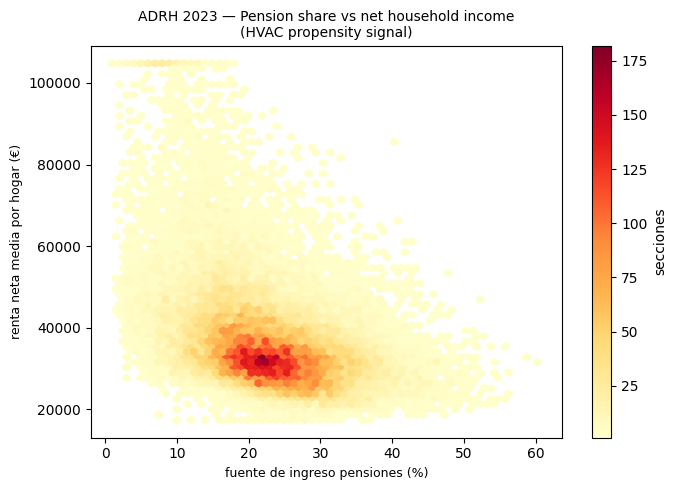

In [11]:
pension_col = next((c for c in source_cols if "pension" in c), None)
income_col  = next((c for c in income_high if re.search(r"neta_media_por_hogar|neta_media_hogar", c)), None)

if pension_col and income_col:
    both = adrh[[pension_col, income_col]].dropna()
    print(f"Secciones with both signals: {len(both):,}")
    plt.figure(figsize=(7, 5))
    plt.hexbin(both[pension_col], both[income_col], gridsize=60, cmap="YlOrRd", mincnt=1)
    plt.colorbar(label="secciones")
    plt.xlabel(pension_col.replace("_", " ") + " (%)", fontsize=9)
    plt.ylabel(income_col.replace("_", " ") + " (€)", fontsize=9)
    plt.title("ADRH 2023 — Pension share vs net household income\n(HVAC propensity signal)", fontsize=10)
    plt.tight_layout()
    plt.show()
    del both
else:
    print(f"Columns not found — pension_col={pension_col}, income_col={income_col}")

## 4. Building a correct wide-format 2023 features file

Pivot the long-format tables to wide, keeping only the 2023 vintage,
then join with `adrh_secciones_renta` (also filtered to 2023).
First inspect what indicators are available in each table.

In [12]:
for table_id in ["30824", "30825", "30826"]:
    df = pd.read_parquet(GENERATED / f"{table_id}_secciones.parquet")
    print(f"\n{table_id}  years={sorted(df['año'].unique())}  n_secciones={df['cod_seccion'].nunique():,}")
    print(f"  indicators:")
    for ind in sorted(df["indicador"].unique()):
        print(f"    {ind}")
    del df
gc.collect()


30824  years=[np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]  n_secciones=36,994
  indicators:
    Dato base. Media de la renta por unidad de consumo. 
    Dato base. Mediana de la renta por unidad de consumo. 
    Dato base. Renta bruta media por hogar. 
    Dato base. Renta bruta media por persona. 
    Dato base. Renta neta media por hogar. 
    Dato base. Renta neta media por persona. 
    Media de la renta por unidad de consumo. Alacant/Alicante sección 03041. 
    Media de la renta por unidad de consumo. Alacant/Alicante sección 08030. 
    Media de la renta por unidad de consumo. Arona sección 01034. 
    Media de la renta por unidad de consumo. Canet de Mar sección 01009. 
    Media de la renta por unidad de consumo. Canet de Mar sección 01010. 
    Media de la renta por unidad de consumo. Cardedeu sección 02005. 
    Media de la renta por unidad de consumo. Cardedeu sección 03002.

37794

In [13]:
def clean_col_name(s: str) -> str:
    """Convert a Spanish ADRH indicator label to a clean snake_case column name."""
    s = re.sub(r"^Dato base\.\s*", "", s)
    s = re.sub(r"^Porcentaje\.\s*", "", s)
    s = re.sub(r"^Total\.\s*", "", s)
    s = re.sub(r"\.\s*Dato base\.\s*$", "", s)
    s = re.sub(r"\.\s*$", "", s)
    s = s.strip().lower()
    for src, tgt in [("á","a"),("é","e"),("í","i"),("ó","o"),("ú","u"),("ñ","n")]:
        s = s.replace(src, tgt)
    s = re.sub(r"[^a-z0-9]+", "_", s)
    return re.sub(r"_+", "_", s).strip("_")

def to_wide_2023(table_id: str, filter_fn=None) -> pd.DataFrame:
    """Filter to 2023, keep only useful indicators, pivot long → wide."""
    df = pd.read_parquet(GENERATED / f"{table_id}_secciones.parquet")
    df = df[df["año"] == 2023].copy()
    if filter_fn:
        df = df[df["indicador"].apply(filter_fn)]
    df["indicador"] = df["indicador"].apply(clean_col_name)
    wide = (
        df.pivot_table(index="cod_seccion", columns="indicador", values="valor", aggfunc="first")
        .reset_index()
    )
    wide.columns.name = None
    print(f"  {table_id}: {len(wide):,} secciones × {wide.shape[1]-1} indicators")
    print(f"  columns: {list(wide.columns[1:])}")
    del df; gc.collect()
    return wide

In [14]:
w24 = to_wide_2023("30824", lambda s: s.strip().startswith("Dato base."))
w25 = to_wide_2023("30825")  # all indicators are actual sección values
w26 = to_wide_2023("30826", lambda s: s.strip().startswith("Total.") and "Dato base" in s)

renta_2023 = (
    pd.read_parquet(GENERATED / "adrh_secciones_renta.parquet")
    .query("periodo == 2023")
    .drop(columns=["cod_provincia", "cod_municipio", "municipio", "periodo"])
)
print(f"  renta_2023: {len(renta_2023):,} secciones × {renta_2023.shape[1]-1} indicators")

adrh_2023 = (
    w24.merge(w25, on="cod_seccion", how="outer")
       .merge(w26, on="cod_seccion", how="outer")
       .merge(renta_2023, on="cod_seccion", how="outer")
)
for c in adrh_2023.select_dtypes("float64").columns:
    adrh_2023[c] = adrh_2023[c].astype("float32")

print(f"\nadrh_2023: {adrh_2023.shape}  |  Memory: {adrh_2023.memory_usage(deep=True).sum()/1e6:.1f} MB")
adrh_2023.head(3)

  30824: 36,354 secciones × 6 indicators
  columns: ['media_de_la_renta_por_unidad_de_consumo', 'mediana_de_la_renta_por_unidad_de_consumo', 'renta_bruta_media_por_hogar', 'renta_bruta_media_por_persona', 'renta_neta_media_por_hogar', 'renta_neta_media_por_persona']
  30825: 35,066 secciones × 5 indicators
  columns: ['fuente_de_ingreso_otras_prestaciones', 'fuente_de_ingreso_otros_ingresos', 'fuente_de_ingreso_pensiones', 'fuente_de_ingreso_prestaciones_por_desempleo', 'fuente_de_ingreso_salario']
  30826: 31,558 secciones × 3 indicators
  columns: ['poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_10_000_euros', 'poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_5_000_euros', 'poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_7_500_euros']
  renta_2023: 4,480 secciones × 6 indicators

adrh_2023: (36395, 21)  |  Memory: 3.6 MB


,cod_seccion,media_de_la_renta_por_unidad_de_consumo,mediana_de_la_renta_por_unidad_de_consumo,renta_bruta_media_por_hogar,renta_bruta_media_por_persona,renta_neta_media_por_hogar,renta_neta_media_por_persona,fuente_de_ingreso_otras_prestaciones,fuente_de_ingreso_otros_ingresos,fuente_de_ingreso_pensiones,...,fuente_de_ingreso_salario,poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_10_000_euros,poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_5_000_euros,poblacion_con_ingresos_por_unidad_de_consumo_por_debajo_de_7_500_euros,renta_media_uc,renta_mediana_uc,renta_bruta_media_hogar,renta_bruta_media_persona,renta_neta_media_hogar,renta_neta_media_persona
0,0100101001,25023.0,22050.0,50398.0,20515.0,41931.0,17069.0,NaN,9.1,NaN,...,70.699997,6.6,2.1,3.8,NaN,NaN,NaN,NaN,NaN,NaN
1,0100101002,23890.0,22050.0,49496.0,18879.0,41604.0,15869.0,NaN,8.9,NaN,...,70.599998,10.4,2.7,5.5,NaN,NaN,NaN,NaN,NaN,NaN
2,0100201001,25523.0,24150.0,50749.0,20631.0,42824.0,17409.0,NaN,11.5,NaN,...,52.500000,9.2,2.6,5.2,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
out = GENERATED / "adrh_secciones_2023_wide.parquet"
adrh_2023.to_parquet(out, index=False)
print(f"Saved: {out}  ({out.stat().st_size/1e6:.1f} MB)")

Saved: data/generated/adrh/adrh_secciones_2023_wide.parquet  (1.4 MB)
